# NB13 — Uji Robustness terhadap Data Non-Wajah

**Tujuan:** menjawab masukan pembimbing seminar hasil — menguji sistem dengan
"data aneh" (foto tanpa wajah) dan menunjukkan di titik mana proses berhenti.

**Kerangka konseptual.** Sistem tidak punya satu titik gagal, melainkan pertahanan
berlapis. Foto yang tidak mengandung wajah TIDAK PERNAH sampai ke tahap embedding
(karena embedding memang embedding wajah) — ia gugur lebih dulu, di tahap deteksi.
Notebook ini memetakan gerbang mana yang menahan tiap jenis input aneh:

| Jenis input | Gugur di | Mekanisme |
|---|---|---|
| File video (`.mov`, dst.) | Gerbang 0 | Whitelist ekstensi (`SUPPORTED_EXT`) — tidak pernah dibaca |
| Foto tanpa wajah (pemandangan, ruangan, objek) | Gerbang 1 | Detektor SCRFD mengembalikan 0 wajah |
| File rusak / tidak terbaca | Gerbang 2 | `try/except` pada loop pembacaan |
| Salah-deteksi (objek/poster lolos sebagai wajah) | Gerbang 3\u20135 | LOF \u2192 noise HDBSCAN \u2192 GLOSH |

**PENTING — notebook ini TIDAK menambahkan foto apa pun ke dataset primer dan TIDAK
menjalankan ulang NB01/NB05/NB10/NB11.** Semua output masuk ke `output_nb13/` baru.
Uji ini berdiri sendiri, sama seperti preseden `EXP_Classical_vs_DL_Restoration.ipynb`
di repo `fotoQu-faceEnhancement` — bukan bagian dari pipeline utama yang menghasilkan
angka Bab IV.

## Bagian 1 — Retrospektif: bukti yang sudah ada di NB01

Sebelum menguji data baru, tunjukkan dulu bahwa Gerbang 0 dan Gerbang 1 SUDAH
teruji secara tidak sengaja saat NB01 memproses dataset asli — buktinya tersimpan,
hanya belum pernah dilaporkan secara eksplisit.

In [2]:
!pip install insightface opencv-python-headless pillow pillow-heif rawpy umap-learn hdbscan -q
!pip install onnxruntime-gpu==1.19.0 -q

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import csv
from pathlib import Path
from collections import Counter, OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from pillow_heif import register_heif_opener
register_heif_opener()

BASE       = Path("/content/drive/MyDrive/OTW S.KOM")
DATA_DIR   = BASE / "DOKUMENTASI OUTDOOR 2025"
NB01_DIR   = BASE / "Embeddings" / "output_nb01"
OUTPUT_DIR = BASE / "Embeddings" / "output_nb13"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup OK.")

Mounted at /content/drive
Setup OK.


In [5]:
# Gerbang 0 — file yang tidak pernah masuk whitelist ekstensi (mis. .mov)
SUPPORTED_EXT = {
    ".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff", ".tif",
    ".heic", ".heif",
    ".raf", ".cr2", ".nef", ".arw", ".dng", ".rw2", ".orf"
}

all_files = [p for p in DATA_DIR.rglob("*") if p.is_file() and not p.name.startswith("._")]
ext_counter = Counter(p.suffix.lower() for p in all_files)

skipped_ext = {ext: n for ext, n in ext_counter.items() if ext not in SUPPORTED_EXT}
kept_ext    = {ext: n for ext, n in ext_counter.items() if ext in SUPPORTED_EXT}

print("=" * 55)
print("  GERBANG 0 \u2014 WHITELIST EKSTENSI")
print("=" * 55)
print(f"  Total berkas       : {len(all_files):,}")
print(f"  Diproses (whitelist): {sum(kept_ext.values()):,}  {dict(kept_ext)}")
print(f"  DITOLAK (bukan citra diam): {sum(skipped_ext.values()):,}  {dict(skipped_ext)}")
print()
print("  Kontrol silang (harus cocok NB01): 2.595 total, 2.533 diproses, 62 .mov ditolak")

assert sum(kept_ext.values()) == 2533, "Jumlah file diproses tidak cocok NB01 \u2014 dataset mungkin berubah"
assert skipped_ext.get(".mov", 0) == 62, "Jumlah .mov tidak cocok NB01"
print("\n\u2713 Cocok dgn NB01 \u2014 dataset sumber terverifikasi konsisten.")

  GERBANG 0 — WHITELIST EKSTENSI
  Total berkas       : 2,595
  Diproses (whitelist): 2,533  {'.jpg': 2392, '.heic': 141}
  DITOLAK (bukan citra diam): 62  {'.mov': 62}

  Kontrol silang (harus cocok NB01): 2.595 total, 2.533 diproses, 62 .mov ditolak

✓ Cocok dgn NB01 — dataset sumber terverifikasi konsisten.


Total baris log        : 98
Foto tanpa wajah (Gerbang 1) : 98
✓ Cocok dgn NB01 (98 foto tanpa wajah).


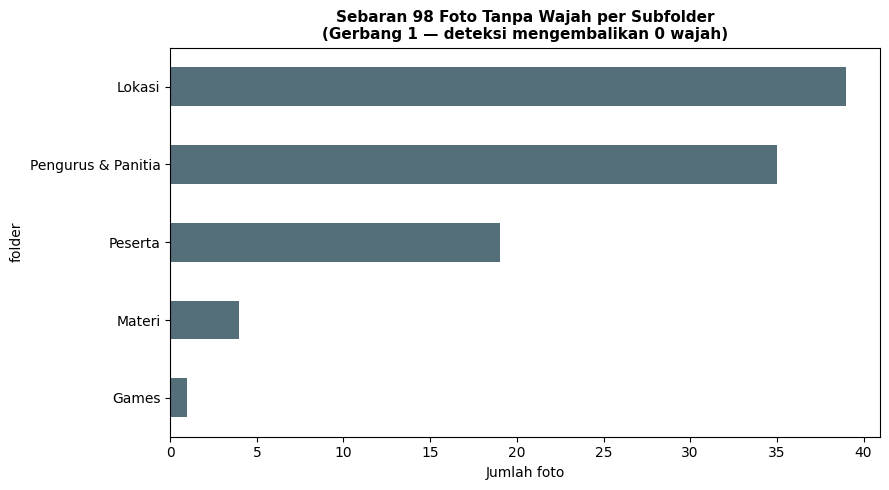

folder
Lokasi                39
Pengurus & Panitia    35
Peserta               19
Materi                 4
Games                  1
Name: count, dtype: int64


In [6]:
# Gerbang 1 — foto yang diproses tapi 0 wajah terdeteksi (log dari NB01)
log_path = NB01_DIR / "skipped_photos_log.csv"
df_skip = pd.read_csv(log_path)
df_noface = df_skip[df_skip["alasan"] == "no_face"].copy()

print(f"Total baris log        : {len(df_skip)}")
print(f"Foto tanpa wajah (Gerbang 1) : {len(df_noface)}")

assert len(df_noface) == 98, "Jumlah foto tanpa wajah tidak cocok catatan NB01 (98)"
print("\u2713 Cocok dgn NB01 (98 foto tanpa wajah).")

df_noface["folder"] = df_noface["foto"].apply(lambda p: str(Path(p).parent))
per_folder = df_noface["folder"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
per_folder.plot(kind="barh", ax=ax, color="#546E7A")
ax.set_title(f"Sebaran 98 Foto Tanpa Wajah per Subfolder\n(Gerbang 1 \u2014 deteksi mengembalikan 0 wajah)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Jumlah foto")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gambar1_sebaran_foto_tanpa_wajah.png", dpi=150, bbox_inches="tight")
plt.show()

print(per_folder)

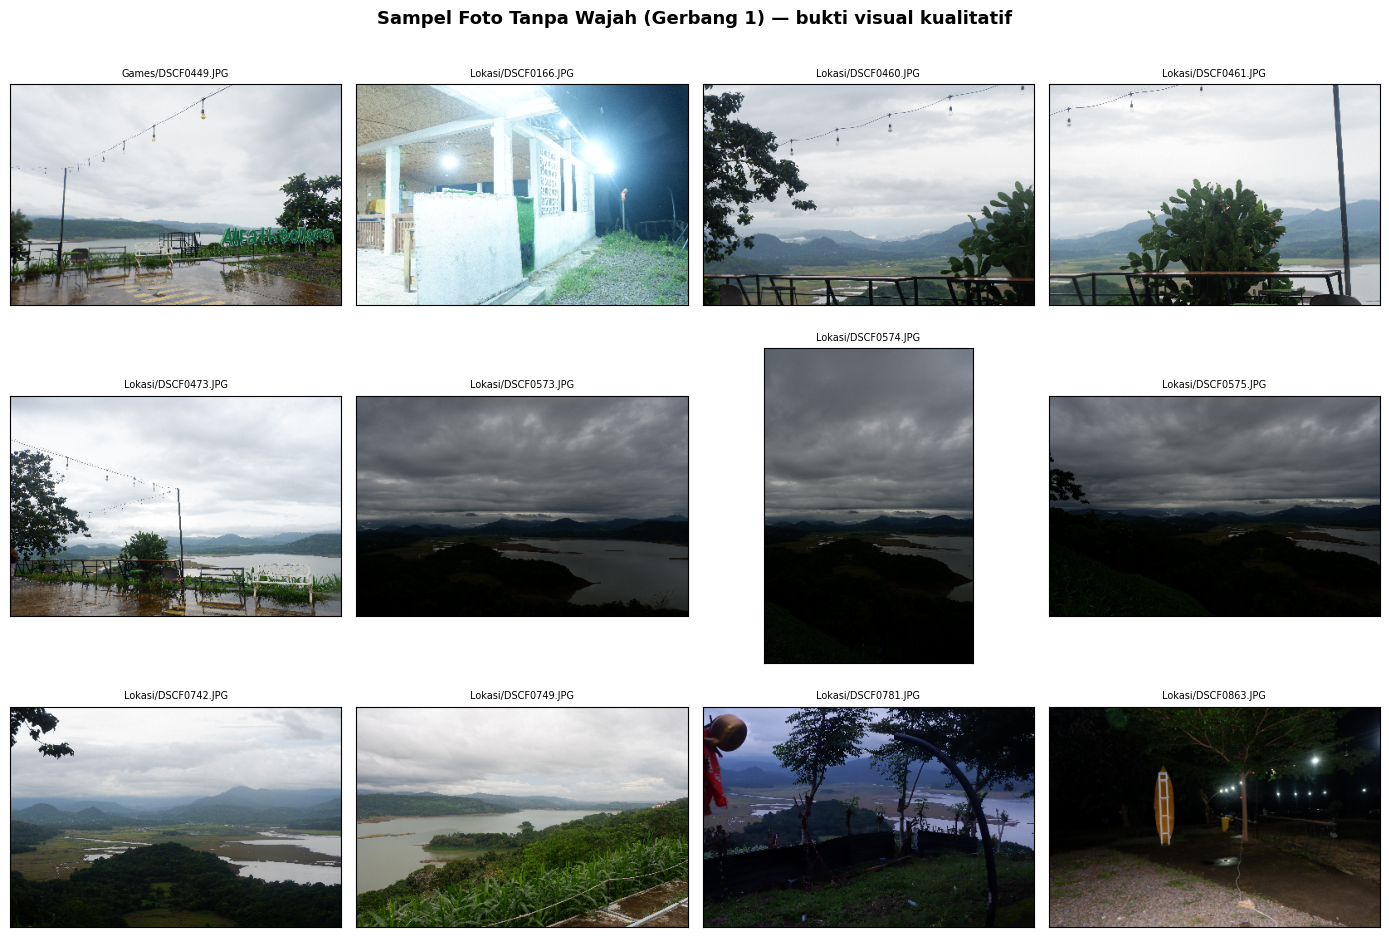

In [7]:
# Sampel visual 12 foto tanpa wajah \u2014 bukti kualitatif (foto UTUH, bukan crop wajah, karena memang tidak ada wajahnya)
RAW_EXTS = {'.raf', '.cr2', '.nef', '.arw', '.dng', '.rw2', '.orf'}

def imread_any(p):
    img = cv2.imread(str(p))
    if img is None:
        ext = Path(p).suffix.lower()
        try:
            if ext in RAW_EXTS:
                import rawpy
                with rawpy.imread(str(p)) as raw:
                    img = cv2.cvtColor(raw.postprocess(), cv2.COLOR_RGB2BGR)
            else:
                from PIL import Image
                img = cv2.cvtColor(np.array(Image.open(p).convert("RGB")), cv2.COLOR_RGB2BGR)
        except Exception:
            img = None
    return img

sample = df_noface["foto"].head(12).tolist()
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.reshape(-1)
for ax, name in zip(axes, sample):
    img = imread_any(DATA_DIR / name)
    if img is not None:
        h, w = img.shape[:2]
        scale = 400 / max(h, w)
        img = cv2.resize(img, (int(w * scale), int(h * scale)))
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(name, fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes[len(sample):]:
    ax.set_visible(False)
fig.suptitle("Sampel Foto Tanpa Wajah (Gerbang 1) \u2014 bukti visual kualitatif", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gambar2_sampel_foto_tanpa_wajah.png", dpi=150, bbox_inches="tight")
plt.show()

## Bagian 2 — Uji prospektif: kategori data "aneh" yang sengaja dikumpulkan

Bagian 1 membuktikan Gerbang 0\u20131 sudah tervalidasi tanpa sengaja. Bagian ini
menguji lebih sistematis dengan kategori yang sengaja dipilih untuk memancing kasus
sulit \u2014 termasuk kategori paling informatif: **spanduk/poster berisi wajah
cetak**, yang berpotensi lolos sebagai deteksi false-positive.

**Sebelum menjalankan sel di bawah:** siapkan folder di Drive, misal
`MyDrive/OTW S.KOM/UJI_NON_WAJAH/`, dengan subfolder:
`pemandangan/`, `objek/`, `dokumen/`, `spanduk_berwajah/`, `punggung/`, `ekstrem/`.
Isi masing-masing dengan foto dari dokumentasi yang sama (bukan sumber luar) agar
distribusi domainnya realistis, bukan artifisial.

In [8]:
import insightface
from insightface.app import FaceAnalysis

has_gpu = False
try:
    import onnxruntime as ort
    has_gpu = 'CUDAExecutionProvider' in ort.get_available_providers()
except Exception:
    pass

# Konfigurasi IDENTIK dengan NB01 \u2014 wajib sama agar uji ini adil (apple-to-apple)
DET_SIZE   = (640, 640)
DET_THRESH = 0.35
CTX_ID     = 0 if has_gpu else -1

face_app = FaceAnalysis(name="buffalo_l", allowed_modules=["detection", "recognition"])
face_app.prepare(ctx_id=CTX_ID, det_size=DET_SIZE, det_thresh=DET_THRESH)

print(f"Model dimuat. GPU: {has_gpu}. DET_THRESH={DET_THRESH} (identik NB01).")

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 95239.57KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
model ignore: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecution

In [10]:
UJI_DIR = BASE / "/content/drive/MyDrive/OTW S.KOM/UJI_NON_WAJAH"   # ganti sesuai path Drive kamu

if not UJI_DIR.exists():
    print(f"[BELUM ADA] {UJI_DIR}")
    print("Buat folder ini dulu di Drive & isi foto sebelum lanjut ke sel berikutnya.")
else:
    # deteksi otomatis: semua subfolder di dalam UJI_DIR dianggap 1 kategori,
    # apa pun namanya — tidak dicocokkan ke daftar tetap lagi
    KATEGORI = sorted(p.name for p in UJI_DIR.iterdir() if p.is_dir())

    if not KATEGORI:
        print(f"[KOSONG] {UJI_DIR} ada, tapi tidak ditemukan subfolder kategori di dalamnya.")
    else:
        for k in KATEGORI:
            n = len(list((UJI_DIR / k).glob("*")))
            print(f"  {k:<20s}: {n} foto")

  FOTO_SPANDUK_DLL    : 26 foto
  Lokasi              : 43 foto


In [11]:
# Jalankan deteksi (SAJA \u2014 tidak ada embedding yang disimpan ke output manapun
# selain output_nb13). Logika baca gambar identik NB01 (cv2 -> rawpy -> PIL).
RAW_EXTS_D = {'.raf', '.cr2', '.nef', '.arw', '.dng', '.rw2', '.orf'}

def read_image(photo_path):
    img = cv2.imread(str(photo_path))
    if img is None:
        ext = photo_path.suffix.lower()
        if ext in RAW_EXTS_D:
            import rawpy
            with rawpy.imread(str(photo_path)) as raw:
                rgb = raw.postprocess()
            img = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
        else:
            from PIL import Image
            pil_img = Image.open(photo_path).convert("RGB")
            img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    return img

rows = []
for kategori in KATEGORI:
    folder = UJI_DIR / kategori
    if not folder.exists():
        continue
    for photo_path in sorted(folder.glob("*")):
        if not photo_path.is_file():
            continue
        try:
            img = read_image(photo_path)
            faces = face_app.get(img)
            if len(faces) == 0:
                rows.append(dict(kategori=kategori, foto=photo_path.name,
                                  n_wajah=0, det_score_max=None, status="Gerbang 1 (0 wajah)"))
            else:
                rows.append(dict(kategori=kategori, foto=photo_path.name,
                                  n_wajah=len(faces),
                                  det_score_max=round(float(max(f.det_score for f in faces)), 4),
                                  status="LOLOS deteksi \u2014 perlu diperiksa manual"))
        except Exception as e:
            rows.append(dict(kategori=kategori, foto=photo_path.name,
                              n_wajah=None, det_score_max=None, status=f"Gerbang 2 (error: {e})"))

df_uji = pd.DataFrame(rows)
df_uji.to_csv(OUTPUT_DIR / "hasil_uji_non_wajah.csv", index=False)
print(f"Total foto diuji: {len(df_uji)}")
df_uji

Total foto diuji: 69


,kategori,foto,n_wajah,det_score_max,status
0,FOTO_SPANDUK_DLL,805D0785-8F87-4D5B-9494-CB9141C2E070.mov,NaN,NaN,Gerbang 2 (error: cannot identify image file '...
1,FOTO_SPANDUK_DLL,DSCF0173.JPG,1.0,0.6205,LOLOS deteksi — perlu diperiksa manual
2,FOTO_SPANDUK_DLL,DSCF0181.JPG,2.0,0.4932,LOLOS deteksi — perlu diperiksa manual
3,FOTO_SPANDUK_DLL,DSCF0182.JPG,5.0,0.5995,LOLOS deteksi — perlu diperiksa manual
4,FOTO_SPANDUK_DLL,DSCF0293.JPG,1.0,0.7322,LOLOS deteksi — perlu diperiksa manual
...,...,...,...,...,...
64,Lokasi,POV_9928.JPG,0.0,NaN,Gerbang 1 (0 wajah)
65,Lokasi,POV_9929.JPG,0.0,NaN,Gerbang 1 (0 wajah)
66,Lokasi,POV_9930.JPG,0.0,NaN,Gerbang 1 (0 wajah)
67,Lokasi,POV_9931.JPG,0.0,NaN,Gerbang 1 (0 wajah)


                  n_foto  n_gerbang1  n_lolos  pct_gerbang1
kategori                                                   
FOTO_SPANDUK_DLL      26          10       15          38.5
Lokasi                43          39        4          90.7


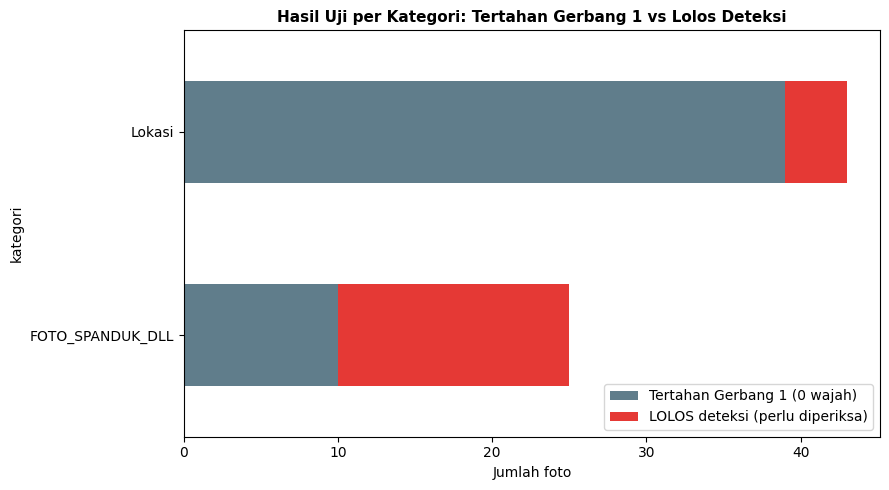

In [12]:
# Ringkasan per kategori
if len(df_uji):
    summary = df_uji.groupby("kategori").agg(
        n_foto=("foto", "count"),
        n_gerbang1=("n_wajah", lambda s: (s == 0).sum()),
        n_lolos=("n_wajah", lambda s: (s.fillna(0) > 0).sum()),
    )
    summary["pct_gerbang1"] = (summary["n_gerbang1"] / summary["n_foto"] * 100).round(1)
    print(summary)

    fig, ax = plt.subplots(figsize=(9, 5))
    summary[["n_gerbang1", "n_lolos"]].plot(kind="barh", stacked=True, ax=ax,
                                             color=["#607D8B", "#E53935"])
    ax.set_title("Hasil Uji per Kategori: Tertahan Gerbang 1 vs Lolos Deteksi",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Jumlah foto")
    ax.legend(["Tertahan Gerbang 1 (0 wajah)", "LOLOS deteksi (perlu diperiksa)"])
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "gambar3_ringkasan_per_kategori.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("df_uji kosong \u2014 isi dulu folder UJI_NON_WAJAH sebelum menjalankan sel ini.")

## Bagian 3 — Nasib hilir: apa yang terjadi bila ada yang lolos Gerbang 1?

Kategori `spanduk_berwajah` (dan mungkin kategori lain) berpotensi menghasilkan
deteksi valid secara teknis \u2014 detektor memang benar ada pola wajah di foto
spanduk. Pertanyaannya bukan "apakah gerbang 1 menahannya" (tidak, karena secara
citra memang ada wajah), tapi **apakah gerbang-gerbang berikutnya (LOF, HDBSCAN,
GLOSH) tetap mengisolasi titik anomali ini** meskipun lolos deteksi.

Sel berikut hanya berjalan bila Bagian 2 menghasilkan minimal satu foto berstatus
"LOLOS deteksi". Embedding titik ini dievaluasi TERHADAP model yang sudah dilatih
dari data asli \u2014 tidak ditambahkan ke `output_nb01/` atau dipakai melatih ulang
apa pun.

In [13]:
import pickle
import joblib
import hdbscan
from sklearn.neighbors import LocalOutlierFactor

lolos_mask = df_uji["n_wajah"].fillna(0) > 0
df_lolos = df_uji[lolos_mask]

if len(df_lolos) == 0:
    print("Tidak ada foto yang lolos Gerbang 1 pada uji ini.")
    print("Ini hasil yang SAH dan kuat: seluruh data aneh yang diuji berhenti di Gerbang 1.")
    print("Laporkan apa adanya \u2014 Bagian 3 tidak perlu dijalankan lebih jauh.")
else:
    print(f"{len(df_lolos)} foto lolos deteksi \u2014 melacak nasibnya di hilir...\n")

    # Muat embedding asli (utk fit LOF novelty) + reducer UMAP + clusterer pass-1
    embeddings_asli = np.load(NB01_DIR / "embeddings.npy")

    NB10_DIR = BASE / "Embeddings" / "output_nb10"
    reducer_umap = joblib.load(NB10_DIR / "umap_reducer.pkl")

    # LOF novelty=True terpisah \u2014 TIDAK menyentuh fit LOF asli (yang novelty=False)
    lof_novelty = LocalOutlierFactor(n_neighbors=20, contamination=0.03, novelty=True)
    lof_novelty.fit(embeddings_asli)

    clusterer_pass1 = hdbscan.HDBSCAN(
        min_cluster_size=15, min_samples=10, metric='euclidean',
        cluster_selection_method='eom', prediction_data=True,
    )
    X_umap = np.load(NB10_DIR / "umap_coords_inlier.npy")
    labels_pass1 = clusterer_pass1.fit_predict(X_umap)
    glosh_scores_ref = clusterer_pass1.outlier_scores_

    GLOSH_HIGH = 0.9
    hasil_hilir = []
    for _, row in df_lolos.iterrows():
        folder = UJI_DIR / row["kategori"]
        photo_path = folder / row["foto"]
        img = read_image(photo_path)
        faces = face_app.get(img)
        for face in faces:
            emb = face.normed_embedding.reshape(1, -1)

            lof_pred = lof_novelty.predict(emb)[0]          # -1 = outlier, 1 = inlier
            status_lof = "DITOLAK LOF (outlier)" if lof_pred == -1 else "lolos LOF"

            if lof_pred == 1:
                emb_umap = reducer_umap.transform(emb)
                label_pred, strength_pred = hdbscan.approximate_predict(clusterer_pass1, emb_umap)
                status_akhir = (
                    f"masuk cluster #{label_pred[0]} (strength={strength_pred[0]:.3f})"
                    if label_pred[0] >= 0 else "NOISE pass-1"
                )
            else:
                status_akhir = "tidak diproses lebih lanjut (sudah ditolak LOF)"

            hasil_hilir.append(dict(
                kategori=row["kategori"], foto=row["foto"],
                det_score=round(float(face.det_score), 4),
                status_lof=status_lof, status_akhir=status_akhir,
            ))

    df_hilir = pd.DataFrame(hasil_hilir)
    df_hilir.to_csv(OUTPUT_DIR / "hasil_nasib_hilir.csv", index=False)
    df_hilir

19 foto lolos deteksi — melacak nasibnya di hilir...

Mon Aug 17 02:04:34 2026 Building and compiling search function


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


...

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


## Ringkasan

In [14]:
print("=" * 60)
print("  RINGKASAN NB13 \u2014 UJI ROBUSTNESS NON-WAJAH")
print("=" * 60)
print(f"  Gerbang 0 (ekstensi ditolak)     : 62 file (.mov)")
print(f"  Gerbang 1 (foto diproses, 0 wajah): 98 foto (dari data asli)")
if 'df_uji' in dir() and len(df_uji):
    print(f"  Uji prospektif \u2014 total diuji  : {len(df_uji)}")
    print(f"  Uji prospektif \u2014 tertahan G1  : {(df_uji['n_wajah'].fillna(-1) == 0).sum()}")
    print(f"  Uji prospektif \u2014 lolos deteksi: {(df_uji['n_wajah'].fillna(0) > 0).sum()}")
print(f"  Output disimpan ke: {OUTPUT_DIR}")
print("=" * 60)

  RINGKASAN NB13 — UJI ROBUSTNESS NON-WAJAH
  Gerbang 0 (ekstensi ditolak)     : 62 file (.mov)
  Gerbang 1 (foto diproses, 0 wajah): 98 foto (dari data asli)
  Uji prospektif — total diuji  : 69
  Uji prospektif — tertahan G1  : 49
  Uji prospektif — lolos deteksi: 19
  Output disimpan ke: /content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb13
